<h1>Синтез аналоговых и дискретных фильтров</h1>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import lfilter, freqz, butter, firls, remez, firwin, firwin2, freqs, cheby1, cheby2, buttord, lfilter_zi
from scipy.fftpack import fft, fftshift

Расчет импульсной характеристики фильтра

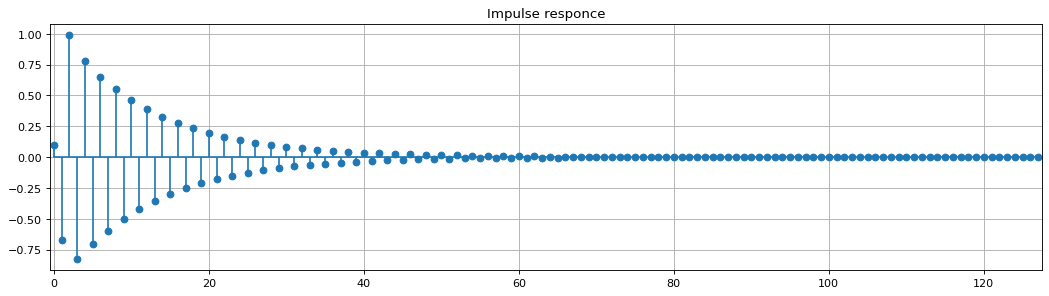

In [ ]:
N = 128
# Дельта-функция
x = np.zeros(N)
x[0] = 1

# Передаточная характеристика фильра в z-форме (H(z)):
# h(z) = [b0 + b1*z^(-1) + b2*z^(-2)] / a0 + a1*z^(-1) + a2*z^(-2)
b = [0.1, -0.6, 0.5]
a = [1, 0.7, -0.2]

# Расчет импульсной характеристики (h(n))
y1 = lfilter(b, a, x)

plt.figure(figsize=(16, 4), dpi=80)
plt.title('Impulse responce')
plt.stem(y1, basefmt='C0')
plt.xlim([-0.5, N-0.5])
plt.grid(True)

Фильтр Баттерворта

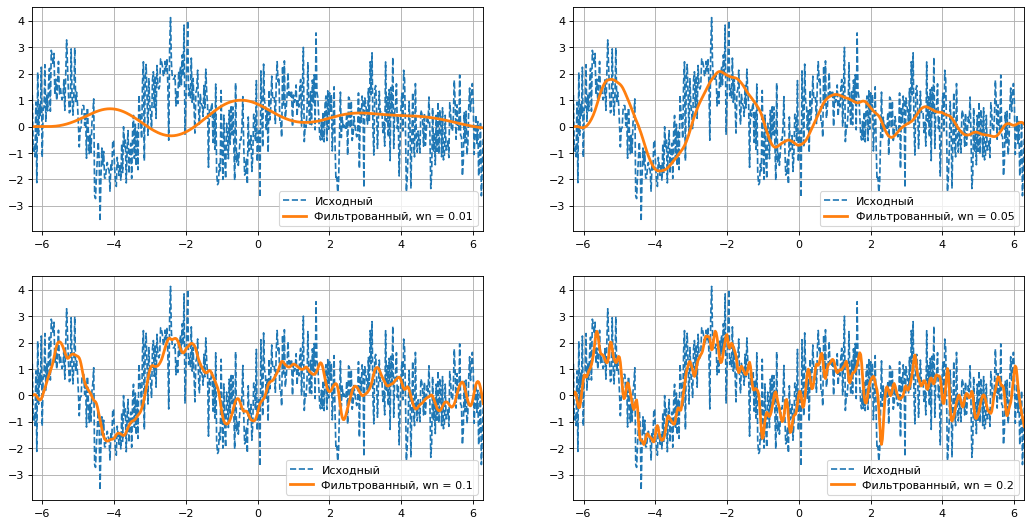

In [ ]:
# Входная последовательность (гармоническая, сумма двух синусоид)
t = 2 * np.pi * np.linspace(-1, 1, 500)
x = np.sin(0.25*t*t)+ 0.95*np.sin(2.0*t)

# Добавляем шум
np.random.seed(1)
xn = x + np.random.randn(len(t))

# строим ФНЧ Баттерворта 3-го порядка. Частота среза (второй параметр) нормируется по частоте Найквиста
b, a = butter(3, 0.2)
z = lfilter(b, a, xn)

wn = [0.01, 0.05, 0.1, 0.2]

# Расчитываем характеристики фильтра для разных значений w
zz = np.zeros((t.size, 4))
for i in range(4):
    b, a = butter(3, wn[i])
    zz[:, i] = lfilter(b, a, xn)

plt.figure(figsize=(16, 8), dpi=80)
for i in range(4):
    plt.subplot(2, 2, i+1)
    plt.plot(t, xn, '--', linewidth=1.5)
    plt.plot(t, zz[:,i], linewidth=2.5)
    plt.xlim([-2 * np.pi, 2 * np.pi])
    plt.grid(True)
    plt.legend(('Исходный', 'Фильтрованный, wn = {}'.format(wn[i])), loc='lower right')

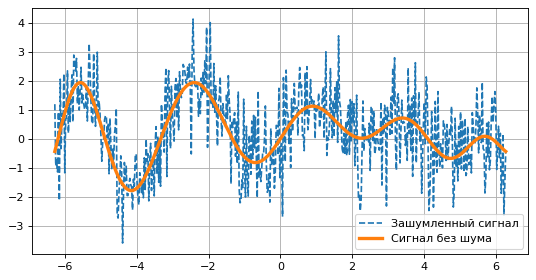

In [ ]:
plt.figure(figsize=(8, 4), dpi=80)
plt.plot(t, xn, '--', linewidth=1.5)
plt.plot(t, x, linewidth=3)
plt.grid(True)
plt.legend(('Зашумленный сигнал', 'Сигнал без шума'), loc='lower right')

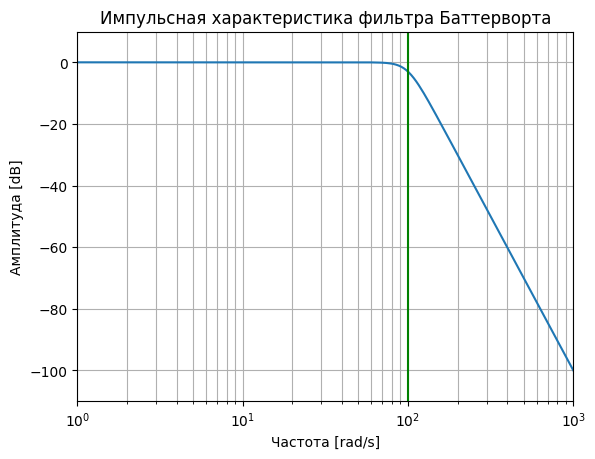

In [ ]:
b, a = butter(5, 100, 'low', analog=True)
w, h = freqs(b, a)
plt.semilogx(w, 20 * np.log10(abs(h)))
plt.title('Импульсная характеристика фильтра Баттерворта')
plt.xlabel('Частота [rad/s]')
plt.ylabel('Амплитуда [dB]')
plt.margins(0, 0.1)
plt.grid(which='both', axis='both')
plt.axvline(100, color='green') # частота среза
plt.show()

Фильтр Чебышева 1-го рода

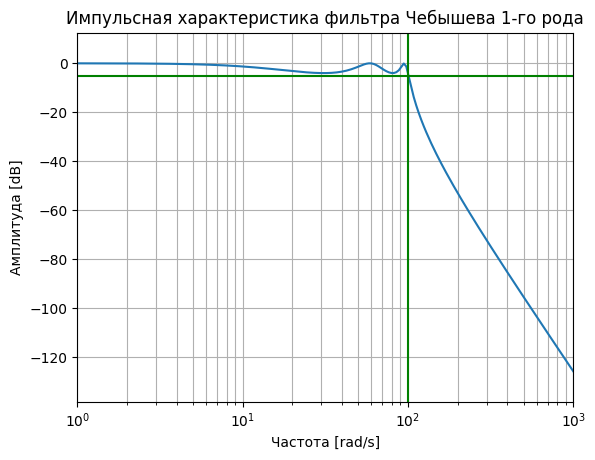

In [ ]:
# 1й параметр - порядок фильтра, 2й - уровень пульсаций (дБ) (rp), 3й - частота среза
b, a = cheby1(5, 4, 100, 'low', analog=True)
w, h = freqs(b, a)
plt.semilogx(w, 20 * np.log10(abs(h)))
plt.title('Импульсная характеристика фильтра Чебышева 1-го рода')
plt.xlabel('Частота [rad/s]')
plt.ylabel('Амплитуда [dB]')
plt.margins(0, 0.1)
plt.grid(which='both', axis='both')
plt.axvline(100, color='green') # частота среза
plt.axhline(-5, color='green') # rp
plt.show()

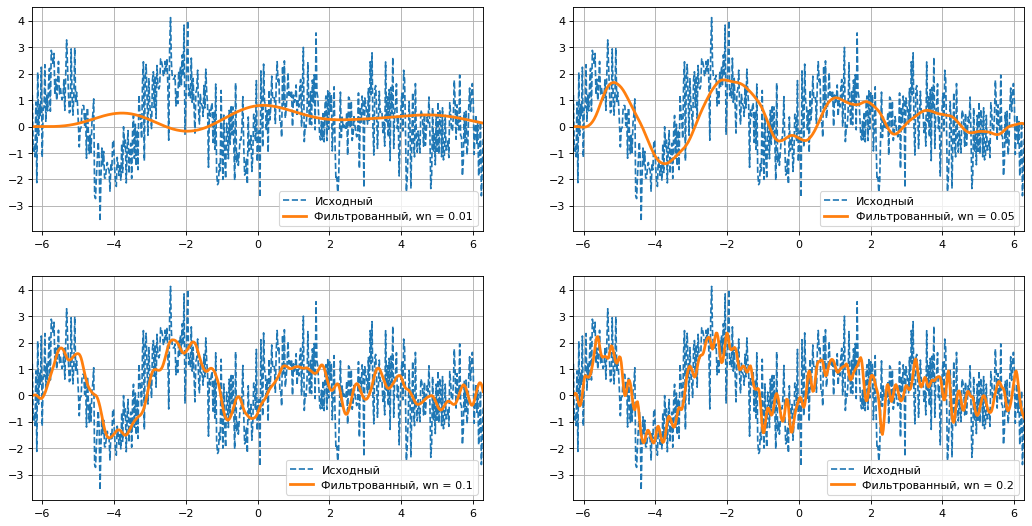

In [ ]:
wn = [0.01, 0.05, 0.1, 0.2]

# Расчитываем характеристики фильтра для разных значений w
zz = np.zeros((t.size, 4))
for i in range(4):
    b, a = cheby1(3, 2, wn[i], 'low')
    zz[:, i] = lfilter(b, a, xn)

plt.figure(figsize=(16, 8), dpi=80)
for i in range(4):
    plt.subplot(2, 2, i+1)
    plt.plot(t, xn, '--', linewidth=1.5)
    plt.plot(t, zz[:,i], linewidth=2.5)
    plt.xlim([-2 * np.pi, 2 * np.pi])
    plt.grid(True)
    plt.legend(('Исходный', 'Фильтрованный, wn = {}'.format(wn[i])), loc='lower right')

Фильтр Чебышева 2-го рода

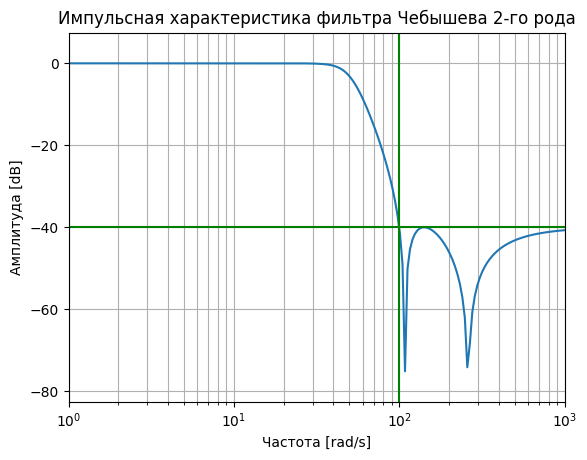

In [ ]:
# 1й параметр - порядок фильтра, 2й - уровень пульсаций (дБ) (rp), 3й - частота среза
b, a = cheby2(4, 40, 100, 'low', analog=True)
w, h = freqs(b, a)
plt.semilogx(w, 20 * np.log10(abs(h)))
plt.title('Импульсная характеристика фильтра Чебышева 2-го рода')
plt.xlabel('Частота [rad/s]')
plt.ylabel('Амплитуда [dB]')
plt.margins(0, 0.1)
plt.grid(which='both', axis='both')
plt.axvline(100, color='green') # частота среза
plt.axhline(-40, color='green') # rp
plt.show()

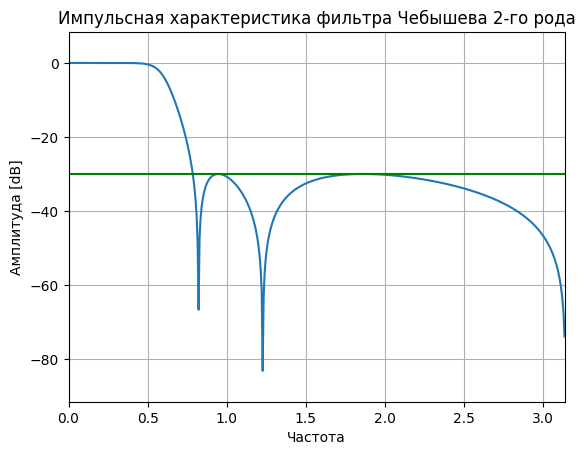

In [ ]:
# 1й параметр - порядок фильтра, 2й - уровень пульсаций (дБ) (rp), 3й - частота среза - для дискретного фильтра в тех же единицах, что и частота дискретизации
# Если частота дискретизации не задана параметром, частота среза задается как доля частоты Найквиста
b, a = cheby2(5, 30, 0.25, 'low')

# частота здесь нормализована [0, pi), для цифрового фильтра используем freqz, а не freqs
w, h = freqz(b, a)
plt.plot(w, 20 * np.log10(abs(h)))
plt.title('Импульсная характеристика фильтра Чебышева 2-го рода')
plt.xlabel('Частота')
plt.ylabel('Амплитуда [dB]')
plt.margins(0, 0.1)
plt.grid(which='both', axis='both')
plt.axhline(-30, color='green') # rp
plt.show()

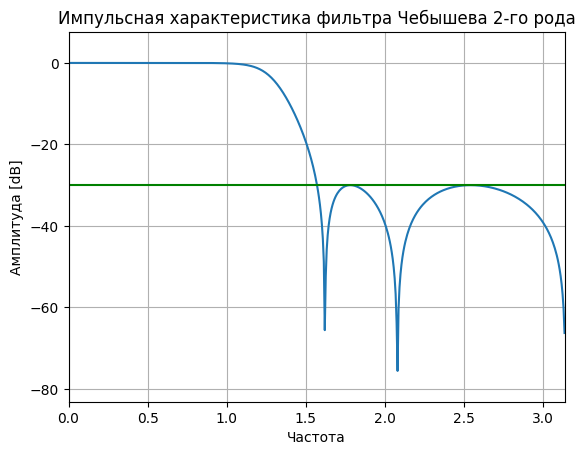

In [ ]:
# 1й параметр - порядок фильтра, 2й - уровень пульсаций (дБ) (rp), 3й - частота среза - для дискретного фильтра в тех же единицах, что и частота дискретизации
# Если частота дискретизации не задана параметром, частота среза задается как доля частоты Найквиста
b, a = cheby2(5, 30, 250, 'low', fs=1000)

# здесь частота Найквиста нормализована [0, pi), тогда, частота дискретизации - [0, 2*pi), для цифрового фильтра используем freqz
w, h = freqz(b, a)
plt.plot(w, 20 * np.log10(abs(h)))
plt.title('Импульсная характеристика фильтра Чебышева 2-го рода')
plt.xlabel('Частота')
plt.ylabel('Амплитуда [dB]')
plt.margins(0, 0.1)
plt.grid(which='both', axis='both')
plt.axhline(-30, color='green') # rp
plt.show()

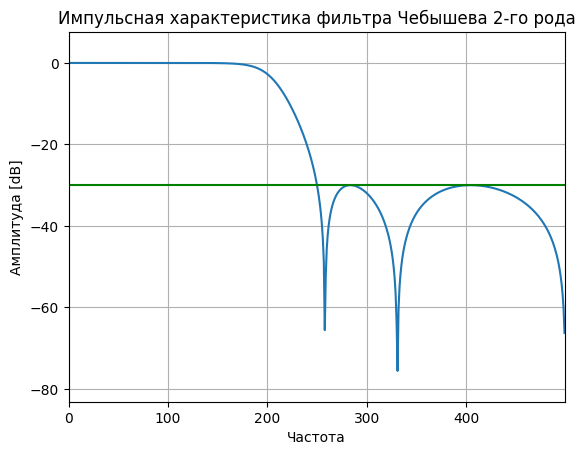

In [ ]:
# 1й параметр - порядок фильтра, 2й - уровень пульсаций (дБ) (rp), 3й - частота среза - для дискретного фильтра в тех же единицах, что и частота дискретизации
# Если частота дискретизации не задана параметром, частота среза задается как доля частоты Найквиста
b, a = cheby2(5, 30, 250, 'low', fs=1000)

# здесь частота Найквиста нормализована [0, pi), тогда, частота дискретизации - [0, 2*pi), для цифрового фильтра используем freqz
w, h = freqz(b, a)
plt.plot(w / (np.pi * 2) * 1000, 20 * np.log10(abs(h))) # переведем частоты в Гц
plt.title('Импульсная характеристика фильтра Чебышева 2-го рода')
plt.xlabel('Частота')
plt.ylabel('Амплитуда [dB]')
plt.margins(0, 0.1)
plt.grid(which='both', axis='both')
plt.axhline(-30, color='green') # rp
plt.show()

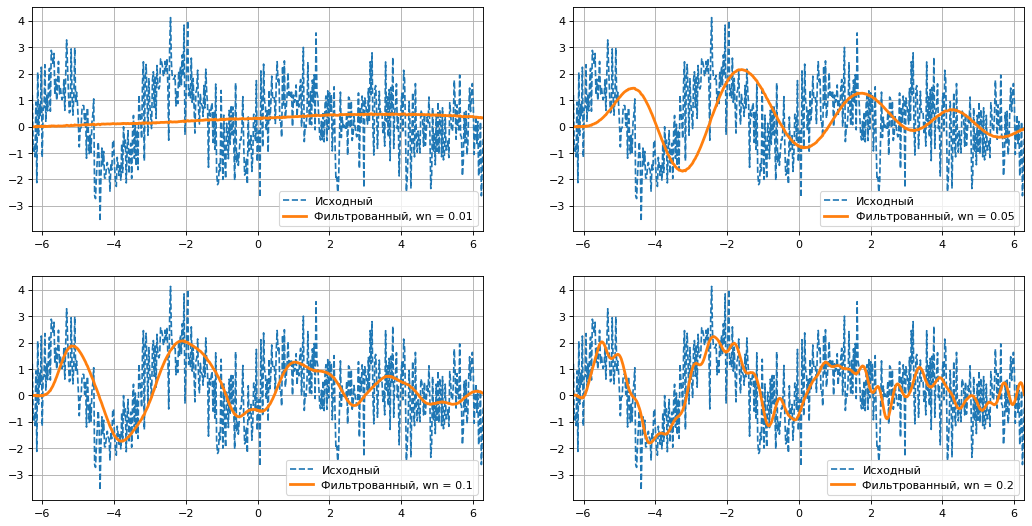

In [ ]:
wn = [0.01, 0.05, 0.1, 0.2]

# Расчитываем характеристики фильтра для разных значений w
zz = np.zeros((t.size, 4))
for i in range(4):
    b, a = cheby2(4, 40, wn[i], 'low')
    zz[:, i] = lfilter(b, a, xn)

plt.figure(figsize=(16, 8), dpi=80)
for i in range(4):
    plt.subplot(2, 2, i+1)
    plt.plot(t, xn, '--', linewidth=1.5)
    plt.plot(t, zz[:,i], linewidth=2.5)
    plt.xlim([-2 * np.pi, 2 * np.pi])
    plt.grid(True)
    plt.legend(('Исходный', 'Фильтрованный, wn = {}'.format(wn[i])), loc='lower right')

<h2>Прямые методы синтеза</h2>

Выбор порядка фильтров

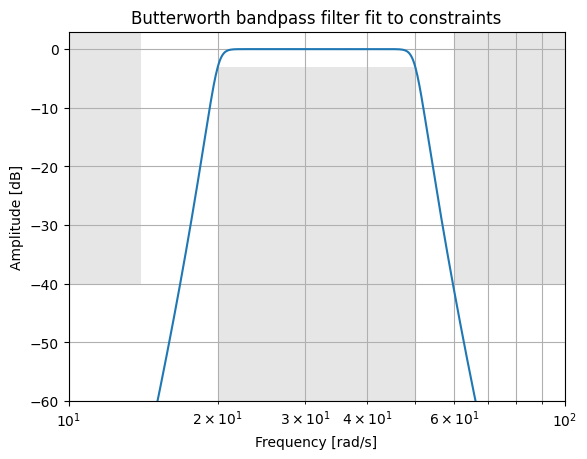

In [ ]:
# возвращает минимальные параметры фильтра
# входные параметры: 1. частоты пропускания, 2. Частоты отсечки  3-4. Максимально допустимый уровень пульсаций в зоне пропускания и в зоне задерживания 5. Аналоговый ли фильтр
# для цифровых фильтров частоты отсечки также задаются в относительных единицах!
N, Wn = buttord([20, 50], [14, 60], 3, 40, True)
b, a = butter(N, Wn, 'band', True)
w, h = freqs(b, a, np.logspace(1, 2, 500))
plt.semilogx(w, 20 * np.log10(abs(h)))
plt.title('Butterworth bandpass filter fit to constraints')
plt.xlabel('Frequency [rad/s]')
plt.ylabel('Amplitude [dB]')
plt.grid(which='both', axis='both')
plt.fill([1,  14,  14,   1], [-40, -40, 99, 99], '0.9', lw=0) # stop
plt.fill([20, 20,  50,  50], [-99, -3, -3, -99], '0.9', lw=0) # pass
plt.fill([60, 60, 1e9, 1e9], [99, -40, -40, 99], '0.9', lw=0) # stop
plt.axis([10, 100, -60, 3])
plt.show()

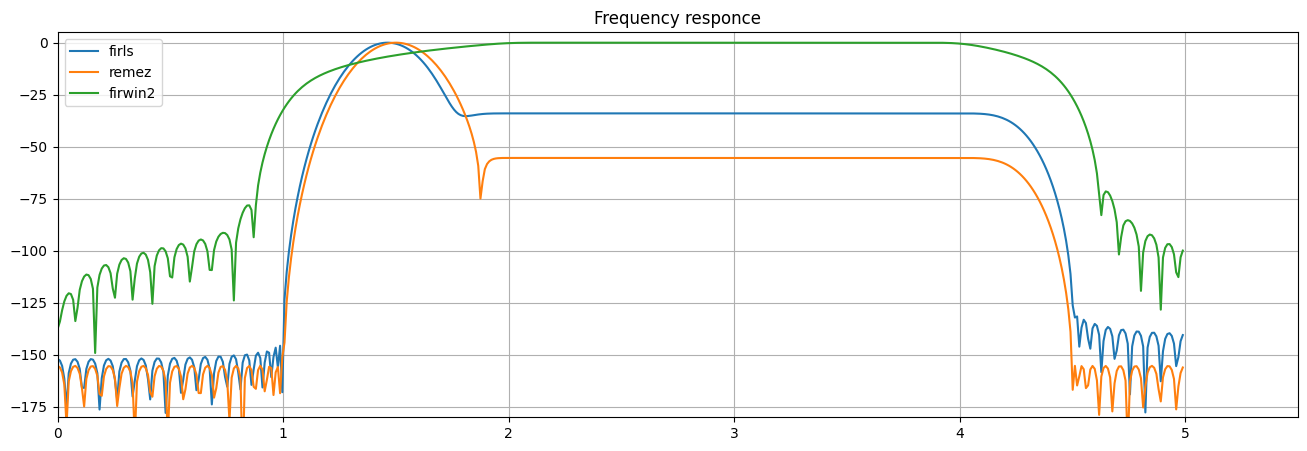

In [ ]:
# Входные параметры
fs = 10
N = 117 # порядок фильтра (должен быть нечетным)
bands = (0, 1, 2, 4, 4.5, 5) # монотонная неубывающая последовательность частот. Все элементы должны быть неотрицательными и меньше или равными частоте Найквиста
desired = (0, 0, 1, 1, 0, 0) # последовательность амплитуд, содержащая требуемое усиление и ослабление на заданных значениях частот из bands

# КИХ-фильтры
fir_firls = firls(N, bands, desired, fs=fs)
fir_remez = remez(N, bands, desired[::2], fs=fs) # здесь только половина желаемых усилений и ослаблений!
fir_firwin2 = firwin2(N, bands, desired, fs=fs) # по умолчанию окно Хэмминга

# АЧХ фильтров
plt.figure(figsize=(16, 5))
plt.title('Frequency responce')
for fir in (fir_firls, fir_remez, fir_firwin2):
    freq, resp = freqz(fir)
    resp = np.abs(resp)
    resp /= np.max(resp) + 10**(-15)
    plt.plot(freq / (np.pi * 2) * 10, 20*np.log10(resp))
plt.xlim([0, 5.5])
plt.ylim([-180, 5])
plt.legend(['firls', 'remez', 'firwin2'], loc ='upper left')
plt.grid(True)

Проектирование ФНЧ, ФВЧ, ПФ и РФ

In [ ]:
def plot_response(w, h, title):
    "Utility function to plot response functions"
    fig = plt.figure()
    ax = fig.add_subplot(111)
    ax.plot(w, 20*np.log10(np.abs(h)))
    ax.set_ylim(-40, 5)
    ax.grid(True)
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Gain (dB)')
    ax.set_title(title)

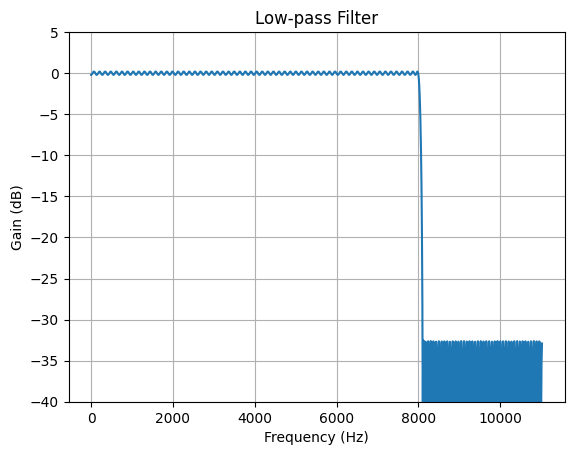

In [ ]:
fs = 22050 # Частота дискретизации, Гц
cutoff = 8000.0    # Частота отсечки, Гц
trans_width = 100  # Ширина перехода от частоты отсечки до подавления, Гц
numtaps = 325      # порядок фильтра
taps = remez(numtaps,
                    [0, cutoff, cutoff + trans_width, 0.5*fs],    # [0, 8000.0, 8100.0, 22050.0]
                    [1, 0],                                       # [0, 8000.0, 8100.0, 22050.0] оставляем первые две, остальные подавляем вплоть до ЧД
                    fs=fs)
w, h = freqz(taps, [1], worN=2048, fs=fs) # worN - число частот, дефолтное - 512 (альтернатива np.linspace(0, fs if whole else fs/2, N, endpoint=include_nyquist))
plot_response(w, h, "Low-pass Filter")
plt.show()

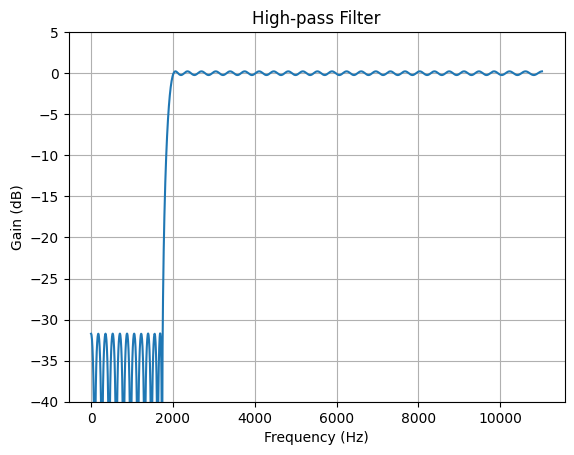

In [ ]:
cutoff = 2000.0    # Частота отсечки, Гц
trans_width = 250  # Ширина перехода от частоты подавления до отсечки, Гц
numtaps = 125      # порядок фильтра
taps = remez(numtaps, [0, cutoff - trans_width, cutoff, 0.5*fs], # [0, 1750.0, 2000.0, 11025.0]
                    [0, 1], fs=fs)
w, h = freqz(taps, [1], worN=2000, fs=fs)
plot_response(w, h, "High-pass Filter")
plt.show()

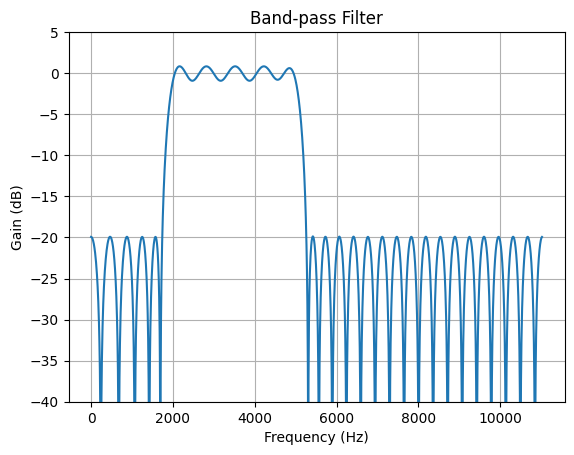

In [ ]:
band = [2000, 5000]  # Частоты отсечки для полосы пропускания, Гц
trans_width = 260    # Ширина перехода от частоты отсечки до подавления, Гц
numtaps = 63         # порядок фильтра
edges = [0, band[0] - trans_width, band[0], band[1],
         band[1] + trans_width, 0.5*fs]       # [0, 1740, 2000, 5000, 5260, 11025.0]
taps = remez(numtaps, edges, [0, 1, 0], fs=fs)
w, h = freqz(taps, [1], worN=2000, fs=fs)
plot_response(w, h, "Band-pass Filter")
plt.show()

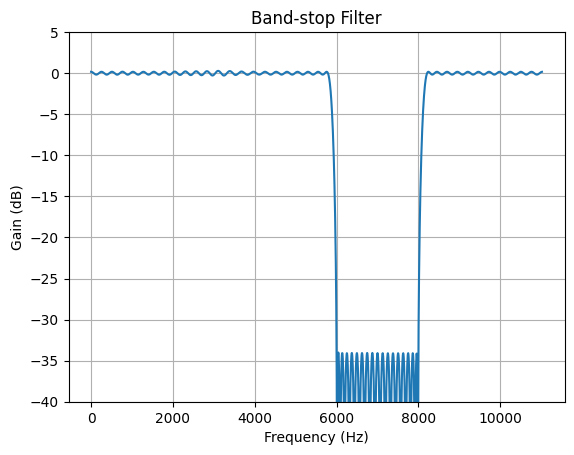

In [ ]:
band = [6000, 8000]  # Частоты отсечки для полосы подавления, Гц
trans_width = 200    # Ширина перехода от частоты отсечки до подавления, Гц
numtaps = 175        # порядок фильтра
edges = [0, band[0] - trans_width, band[0], band[1],
         band[1] + trans_width, 0.5*fs]               # [0, 5800, 6000, 8000, 8200, 11025.0]
taps = remez(numtaps, edges, [1, 0, 1], fs=fs)
w, h = freqz(taps, [1], worN=2000, fs=fs)
plot_response(w, h, "Band-stop Filter")
plt.show()